     areakey  zonei        lat       lon  osgb36_east  osgb36_north       area
0  E02000001      0  51.515000 -0.090516    532482.75     181269.56  2897837.5
1  E02000002      1  51.588420  0.141110    548312.70     189878.02  2161565.0
2  E02000003      2  51.575100  0.142558    548456.44     188399.88  2141516.0
3  E02000004      3  51.555622  0.178484    551010.00     186307.53  2492948.0
4  E02000005      4  51.561592  0.144949    548666.10     186902.60  1187953.0
5  E02000007      5  51.558270  0.159004    549651.06     186562.12  1735997.9
6  E02000008      6  51.552820  0.136958    548140.90     185910.88  1419999.0
7  E02000009      7  51.551743  0.119994    546968.44     185757.10   960733.6
8  E02000010      8  51.547050  0.150028    549065.60     185296.10  1121450.5
9  E02000011      9  51.545460  0.170756    550507.80     185161.84  1594084.6
ZoneCodes has 8436 rows


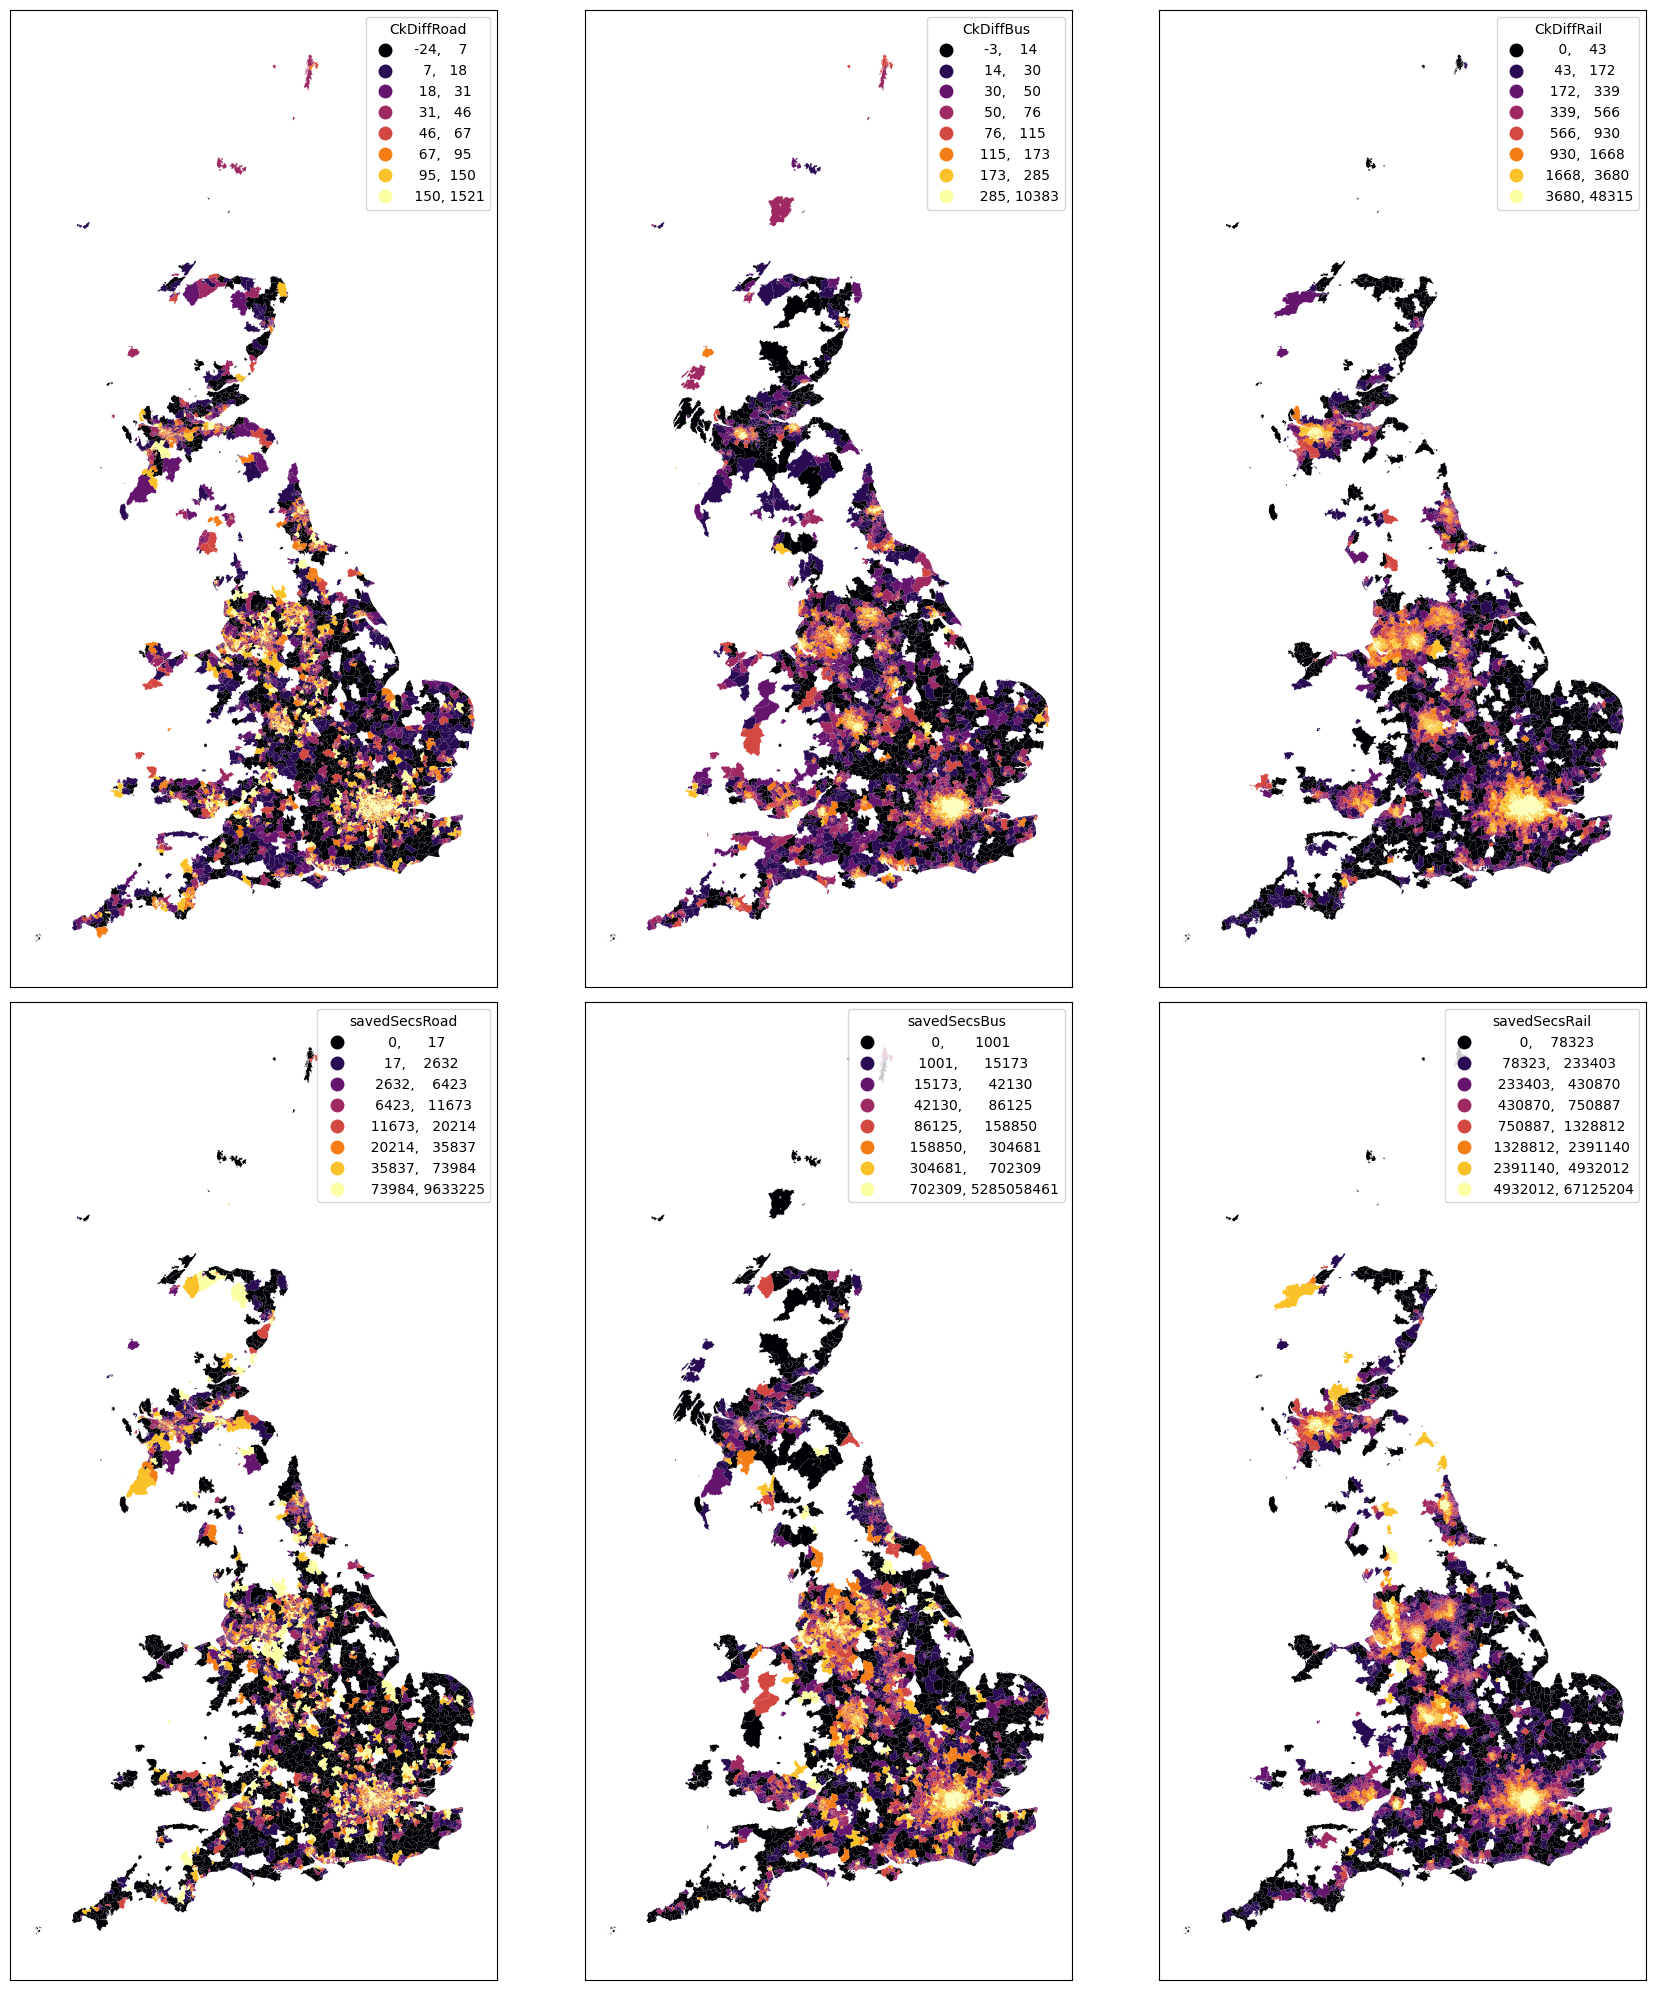

In [31]:
"""
This is based on Alison's mapping code, but modified to draw the maps relevant to the paper.
"""

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.express as px
import contextily as cx
import cartopy.crs as ccrs
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

#plot map of mean score for msoa iz zones
#NOTE: we always map the 'impact' column, which needs to be set beforehand
#AND... the shapefile is pre-loaded as merged_ews from the main code
#axs is the subplot that we're plotting into
def plot_quantiles(axs, impacts_df, field_name):
    #print(impacts_df.columns)
    #impacts_df.to_csv("outputs/impacts_df.csv")
    # - retrieve unique zone numbers -
    neti = impacts_df['net_i'].unique()
    df_mean = []

    #for each unqiue zone number, calculate mean score by zone that appeared in i/ j
    for i in neti:
        #mean_score = impacts_df.loc[(impacts_df[' net_i'] == i) | (impacts_df[' net_j'] == i), 'CkDiffRoad'].mean()
        #subset_df = pd.DataFrame({' net_i': [i], 'CkDiffRoad': [mean_score]})
        mean_score = impacts_df.loc[(impacts_df['net_i']==i),field_name].mean()
        #mean_score = impacts_df.loc[(impacts_df['net_i']==i),'impact'].max()
        subset_df = pd.DataFrame({'net_i': [int(i)], 'impact': [mean_score]}) #save as column name='impact' in table to be mapped later
        df_mean.append(subset_df)

    df_mean = pd.concat(df_mean, ignore_index=True)
    #df_mean.to_csv("outputs/map.csv")
    #print('df_mean\n')
    #print(df_mean.head(10))

    #merge to retrive geometry 
    #df_mean = df_mean.merge(ews_i[[' net_i', 'zonei_geom']], on = ' net_i', how = 'left')
    #print(merged_ews.columns)
    df_mean = df_mean.merge(merged_ews[['zonei', 'geometry']], left_on = 'net_i', right_on='zonei', how = 'left')
    df_mean = df_mean.set_geometry('geometry')

    #plot with quantiles scheme 
    ax = df_mean.plot(ax = axs, column='impact', scheme='Quantiles', k=8, cmap='inferno', legend=True, figsize=(9.0, 15.5), legend_kwds={'title': field_name, "fmt": "{:.0f}"})
    #cx.add_basemap(ax, crs=df_mean.crs, source=cx.providers.CartoDB.PositronNoLabels)

    #export
    #plt.savefig("outputs/CkDiffRoad_quantile.png", transparent=True)

################################################################################
#main code

#read zone codes and msoa shapefile 
#ews_zones = pd.read_csv('inputs/model-runs/EWS_ZoneCodes.csv')
#msoa = gpd.read_file('inputs/model-runs/EnglandWalesScotland_IZ_MSOA_2011.shp')
#boundary = gpd.read_file('inputs/model-runs/TCITY_2015_EW_BGG_V2.shp')
#boundary_scot = gpd.read_file('inputs/model-runs/Localities2020_MHW.shp')

ZoneCodesFilename = r'data/DAFNI_SCQUAIR/EWS_ZoneCodes.xml'
MSOAFilename = r'data/geography/EnglandWalesScotland_IZ_MSOA_2011.shp'
resultsFilename = r'outputs/OiDj_merged.csv'
#output_file = r'outputs/geo_OiDj_merged.csv'

#load zone codes xml file into a pandas dataframe
with open(ZoneCodesFilename) as f:
    df_ZoneCodes = pd.read_xml(f)
    print(df_ZoneCodes.head(10))
    print("ZoneCodes has "+str(len(df_ZoneCodes.index))+" rows")

#load the msoa shapefile
msoa = gpd.read_file(MSOAFilename)

#read the results file
results_df = pd.read_csv(resultsFilename)

#merge shapefile with zone codes
merged_ews = df_ZoneCodes.merge(msoa, left_on='areakey', right_on='msoa_iz')
#print(merged_ews.head(10))

fig, axs = plt.subplots(2, 3, figsize=(18, 20))
modes = {0: 'Road', 1: 'Bus', 2: 'Rail'}
impacts_Ck = { 0:'CkDiffRoad', 1:'CkDiffBus', 2:'CkDiffRail'}
impacts_secs = { 0:'savedSecsRoad', 1:'savedSecsBus', 2:'savedSecsRail'}
#colours = {0: 'blue', 1: 'green', 2: 'orange'}


for i, mode in enumerate(modes.keys()):
    mode_data = results_df[results_df['net_mode'] == i]
    plot_quantiles(axs[0,i],mode_data,impacts_Ck[i])
    plot_quantiles(axs[1,i],mode_data,impacts_secs[i])
    #axs[0,i].set_axis_off()
    #axs[1,i].set_axis_off()
    axs[0,i].set_xticks([])
    axs[0,i].set_yticks([])
    axs[1,i].set_xticks([])
    axs[1,i].set_yticks([])
#and save the figure
plt.tight_layout()
plt.savefig("outputs/maps_CkDiff_SavedSecs_quantile.png")
plt.show()

CORRELATIONS

In [ ]:
"""
Correlation code and plots
YOU DON'T NEED THIS AS IT'S IN geography-impacts.ipynb
"""

import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt

#read the results file
results_df = pd.read_csv(resultsFilename)

fig, axs = plt.subplots(2, 3, figsize=(18, 20))
modes = {0: 'Road', 1: 'Bus', 2: 'Rail'}
impacts_Ck = { 0:'CkDiffRoad', 1:'CkDiffBus', 2:'CkDiffRail'}
impacts_secs = { 0:'savedSecsRoad', 1:'savedSecsBus', 2:'savedSecsRail'}
colours = {0: 'blue', 1: 'green', 2: 'orange'}

for i, label in enumerate(modes.keys()):
    mode_data = results_df[results_df['net_mode'] == i]
    r = scipy.stats.pearsonr(mode_data[impacts_Ck[i]], mode_data[impacts_secs[i]]).correlation #Pearson r
    axs[0,i].scatter(mode_data[impacts_Ck[i]], mode_data[impacts_secs[i]], alpha=0.5, color=colours[mode], label=f'{label} r='+str(round(r,2)))
    axs[0,i].set_xlabel('Total Network Saved Seconds')
    axs[0,i].set_ylabel('Count People Changing Mode')
    axs[0,i].set_title(f'Impact Compared to Total Network Change ({label})')
